**CAB213:APPLIED AI-COMPUTER VISION AND NATURAL LANGUAGE
PROCESSING**


**Project Title: Flower Classification Using Applied AI**


*   Submitted by: Chandana Reddy Chowtoori
*   Registeration No :12413506
*   Roll No: 20
*   Section: D2411/G1
*   Course Code: CAB114

**Description:**

This project classifies flower images into five categories: Daisy, Dandelion, Rose, Sunflower, and Tulip using deep learning. Images are resized and normalized, and a simple neural network is trained for classification. After training, the model predicts flower classes and provides a short textual report describing each flower. The project also includes accuracy and loss visualization for evaluation.

In [28]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt
import numpy as np

print("Libraries loaded!")

Libraries loaded!


In [29]:
(ds_train, ds_test), ds_info = tfds.load(
    "tf_flowers",
    split=["train[:80%]", "train[80%:]"],  # 80% train, 20% test
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

num_classes = ds_info.features['label'].num_classes
print("Number of classes:", num_classes)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.LLGNEA_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Number of classes: 5


In [30]:
IMG_SIZE = 64  # small for simplicity

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0  # normalize
    return image, label

ds_train = ds_train.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)
ds_test = ds_test.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)

In [31]:
model = Sequential([
    Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,573,637 (6.00 MB)

 Trainable params: 1,573,637 (6.00 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
history = model.fit(
    ds_train,
    validation_data=ds_test,
    epochs=5
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.2933 - loss: 2.8551 - val_accuracy: 0.4019 - val_loss: 1.4435
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.4427 - loss: 1.3296 - val_accuracy: 0.4251 - val_loss: 1.4461
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.4660 - loss: 1.2891 - val_accuracy: 0.4223 - val_loss: 1.4734
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.4782 - loss: 1.2639 - val_accuracy: 0.4210 - val_loss: 1.5866
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.4956 - loss: 1.2392 - val_accuracy: 0.4264 - val_loss: 1.6079


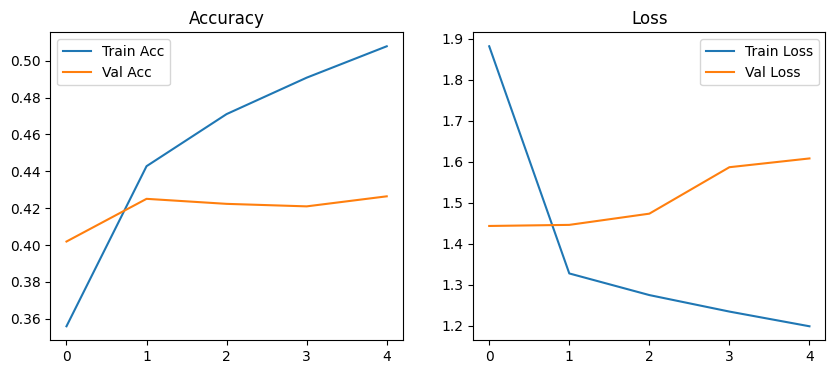

In [33]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title("Loss")
plt.show()

In [35]:
flower_report = {
    0: "Daisy: Simple and charming.",
    1: "Dandelion: Bright and cheerful.",
    2: "Roses: Elegant and classic.",
    3: "Sunflowers: Tall and radiant.",
    4: "Tulips: Colorful and graceful."
}
for img, label in ds_test.take(1):
    pred = model.predict(img)
    class_index = np.argmax(pred[0])
    print("Predicted class index:", class_index)
    print("Flower info:", flower_report[class_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Predicted class index: 0
Flower info: Daisy: Simple and charming.


In [38]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/content/Beautiful-Flowers.jpg.webp"

img = image.load_img(img_path, target_size=(64,64))
img_array = np.expand_dims(np.array(img)/255.0, axis=0)

pred = model.predict(img_array)
class_index = np.argmax(pred[0])
print("Predicted class index:", class_index)
print("Flower info:", flower_report[class_index])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Predicted class index: 2
Flower info: Roses: Elegant and classic.


In [39]:
from sklearn.metrics import classification_report
y_true = []
y_pred = []

for images, labels in ds_test:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=list(flower_report.values())))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
                                 precision    recall  f1-score   support

    Daisy: Simple and charming.       0.33      0.72

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [40]:
model.save("/content/flower_classifier_model.h5")
print("Model saved!")


Model saved!


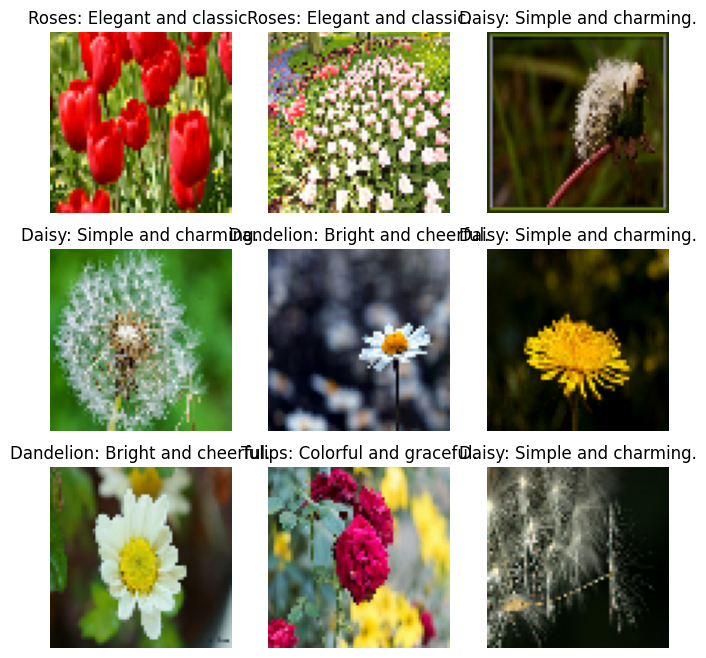

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

for i, (image, label) in enumerate(ds_train.take(9)):
    plt.subplot(3,3,i+1)
    plt.imshow(image[0].numpy())  # Show first image in batch
    plt.title(list(flower_report.values())[label[0].numpy()])
    plt.axis('off')

plt.show()
